# ML data configuration reference

A source configuration maps one patch to an array. It determines tensor layout,
batching behavior, representation of unavailable data, and retained native
resolution. Each example shows its output structure and missing-data behavior.

`Resample` fixes the output grid. `Native` keeps the source grid. `VectorPair`
produces a two-component field, and `Points` returns ragged records.

All examples use the same pinned catalog revision, published eval QuerySet,
and drawn row. Differences therefore come from the source configuration.

For an end-to-end training loader, see the
[ML use cases notebook](spatio_temporal_query_generation.ipynb). For filters
and coverage, see the
[QuerySet and filter deep-dive](data_retrieval_workflows.ipynb).

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

def _format_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _format_warning

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    import matplotlib.pyplot as plt
    plt.close(fig)

PATCH_SIZE_KM = 256
REQUESTED_ROWS = 4
SEED = 7

DRAW_DIR = Path("draws")
DRAW_DIR.mkdir(exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
plt.ioff()
import numpy as np
from math import cos, radians

CMAP = "RdBu_r"

COLOR_RANGE = {
    "l4_sst": (2.0, 32.0),
    "l4_ssh": (-0.5, 0.5),
    "l3_swot": (-0.5, 0.5),
    "l3_ssh": (-0.5, 0.5),
    "l4_sss": (32.0, 38.0),
    "velocity": (-0.8, 0.8),
    "speed": (0.0, 0.8),
    "argo_temp": (0.0, 30.0),
}

UNITS = {
    "l4_sst": "degC",
    "l4_ssh": "m",
    "l3_swot": "m",
    "l3_ssh": "m",
    "l4_sss": "PSU",
    "velocity": "m/s",
    "speed": "m/s",
    "argo_temp": "degC",
}

QUANTITY = {
    "l4_sst": "sea surface temperature",
    "l4_ssh": "sea surface height anomaly",
    "l3_swot": "sea surface height anomaly",
    "l3_ssh": "sea surface height anomaly",
    "l4_sss": "sea surface salinity",
    "velocity": "current velocity component",
    "speed": "current speed",
    "argo_temp": "temperature",
}

def color_limits(key):
    low, high = COLOR_RANGE.get(key, (None, None))
    return {"vmin": low, "vmax": high}

def source_label(token, shape=None):
    unit = UNITS.get(token)
    parts = [token]
    if shape is not None:
        parts.append(f"{shape[0]}x{shape[1]}")
    return " ".join(parts) + (f" [{unit}]" if unit else "")

def colorbar_label(token):
    quantity, unit = QUANTITY.get(token), UNITS.get(token)
    if quantity and unit:
        return f"{quantity} [{unit}]"
    return QUANTITY.get(token) or (f"[{unit}]" if unit else "")

def add_colorbar(fig, drawn, axes, token, shrink=.7):
    bar = fig.colorbar(drawn, ax=axes, shrink=shrink, label=colorbar_label(token))
    low, high = COLOR_RANGE.get(token, (None, None))
    if low is not None:
        bar.set_ticks(np.linspace(low, high, 5))
    return bar

import cartopy.io.shapereader as shpreader
from functools import lru_cache
from matplotlib.collections import LineCollection

@lru_cache(maxsize=None)
def _coastline_segments(resolution):
    path = shpreader.natural_earth(resolution=resolution, category="physical", name="coastline")
    segments = []
    for geometry in shpreader.Reader(path).geometries():
        parts = geometry.geoms if geometry.geom_type == "MultiLineString" else [geometry]
        segments.extend(np.asarray(part.coords) for part in parts)
    return tuple(segments)

def add_coastlines(axis, resolution=None, color="#444444", linewidth=.7, alpha=.85):
    lon_min, lon_max = sorted(axis.get_xlim())
    lat_min, lat_max = sorted(axis.get_ylim())
    if resolution is None:
        span = max(lon_max - lon_min, lat_max - lat_min)
        resolution = "110m" if span > 60 else "50m" if span > 8 else "10m"
    visible = []
    for coords in _coastline_segments(resolution):
        lon, lat = coords[:, 0], coords[:, 1]
        if lat.max() < lat_min or lat.min() > lat_max:
            continue
        for shift in (0.0, -360.0, 360.0):
            shifted = lon + shift
            if shifted.max() >= lon_min and shifted.min() <= lon_max:
                visible.append(np.column_stack([shifted, lat]))
    if visible:
        axis.add_collection(LineCollection(visible, colors=color, linewidths=linewidth,
                                           alpha=alpha, zorder=2.5))
    axis.set_xlim(lon_min, lon_max)
    axis.set_ylim(lat_min, lat_max)
    return axis

def geographic_extent(record):
    lon = np.asarray(record["lon"]).ravel()
    lat = np.asarray(record["lat"]).ravel()
    return (float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max()))

def map_aspect(extent):
    lon_min, lon_max, lat_min, lat_max = extent
    mid = radians((lat_min + lat_max) / 2)
    return 1.0 / max(cos(mid), 1e-6)

def batch_member(batch, token, index):
    stacked = batch[token]
    record = {key: stacked[key][index] for key in ("data", "valid_mask", "lat", "lon")
              if key in stacked}
    for key in ("source_valid", "support_mask", "spatial_padding_mask"):
        if key in stacked:
            record[key] = stacked[key][index]
    return record

def batch_panel_grid(batch, token, columns=4, day=0, title=None, panel_title=None,
                     figure_width=3.3, panel_height=3.0, show_coastlines=True):
    values = np.asarray(batch[token]["data"])
    count = values.shape[0]
    rows = int(np.ceil(count / columns))
    fig, axes = plt.subplots(rows, columns, squeeze=False,
                             figsize=(figure_width * columns, panel_height * rows),
                             constrained_layout=True)
    flat = axes.ravel()
    limits = color_limits(token)
    available = batch.get("availability", {}).get(token, [True] * count)
    drawn = None
    for index in range(count):
        axis, record = flat[index], batch_member(batch, token, index)
        axis.set(xticks=[], yticks=[])
        axis.set_title(panel_title(batch, index) if panel_title else f"row {index}", fontsize=9)
        extent = geographic_extent(record)
        if not available[index] or not np.isfinite(extent).all():
            axis.text(.5, .5, "no data\nfor this row", ha="center", va="center",
                      fontsize=9, color="#777777", transform=axis.transAxes)
            continue
        field = np.asarray(record["data"])[day]
        shown = np.where(np.asarray(record["valid_mask"])[day], field, np.nan)
        drawn = axis.imshow(shown, origin="lower", cmap=CMAP, interpolation="nearest",
                            aspect=map_aspect(extent), extent=extent, **limits)
        if show_coastlines:
            add_coastlines(axis)
    for axis in flat[count:]:
        axis.axis("off")
    if drawn is not None:
        add_colorbar(fig, drawn, axes.ravel().tolist(), token, shrink=.6)
    heading = f"{title} -- {source_label(token)}" if title else source_label(token)
    fig.suptitle(heading, fontsize=11)
    return fig

def batch_dates(batch):
    return [f"{spec.context.start:%Y-%m-%d}" for spec in batch["query"]]

In [3]:
from ocean_taco import CatalogConfig, QuerySet
from ocean_taco.retrieve import load_hf_dataset

config = CatalogConfig()
catalog = load_hf_dataset(config)
queryset = QuerySet.from_hub(PATCH_SIZE_KM, "eval")
print(f"queryset_id={queryset.queryset_id}; kind={queryset.header['kind']}; positions={len(queryset.positions)}; dates={len(queryset.dates)}")

queryset_id=2b55f024f45630d5a81546832a108ed99648c4d7b5024d79a21b1f0851ef4f18; kind=eval; positions=6027; dates=858


## The row every configuration uses

Every configuration uses the same drawn row, isolating configuration effects.
The helpers print tensor shapes and masks, source availability, and an array
view.

The draw requires recorded SWOT and SSH coverage, so the shared row includes
sparse and dense sources. The [deep-dive](data_retrieval_workflows.ipynb)
explains those coverage requirements.

In [ ]:
from ocean_taco import CoverageRequirement, GeoBox, PatchSize, QueryFilter, draw_queryset, select_queryset
from ocean_taco.render import Native, Points, Resample, VectorPair
from ocean_taco.torch import OceanTACODataset

shared_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                            record_path=DRAW_DIR / "cookbook-draw.json",
                            query_filter=QueryFilter(box=GeoBox(-80, -30, 10, 45),
                                                     coverage=(CoverageRequirement("swot", "valid_fraction_ocean", 0.2),
                                                               CoverageRequirement("ssh", "valid_cells", 1))))
row = shared_draw.rows[0]
print(f"row: ({row['centre_lon']:.2f}, {row['centre_lat']:.2f}) on {row['anchor_time'][:10]}")

def render(sources):
    sample = OceanTACODataset(queries=shared_draw, sources=sources, catalog_config=config)[0]
    for token in sources:
        record, available = sample[token], sample["availability"][token]
        shape = tuple(np.asarray(record["data"]).shape)
        valid = int(np.asarray(record["valid_mask"]).sum())
        print(f"  {token:10s} data={str(shape):18s} available={str(available):5s} valid_cells={valid}")
    return sample

def show_grid(axis, record, title, component=None, key=None):
    data = np.asarray(record["data"])
    if data.shape[0] == 0:
        axis.text(.5, .5, "structurally absent for\nthis position and date", ha="center", va="center", transform=axis.transAxes)
        axis.set(title=f"{title}: shape {data.shape}", xticks=[], yticks=[])
        return
    image = data[0] if component is None else data[0][component]
    extent = geographic_extent(record)
    drawn = axis.imshow(image, origin="lower", cmap=CMAP, interpolation="nearest",
                        aspect=map_aspect(extent), extent=extent, **color_limits(key))
    axis.set(title=f"{title}: shape {data.shape}", xlabel="longitude [°]", ylabel="latitude [°]")
    add_coastlines(axis)
    axis.figure.colorbar(drawn, ax=axis, shrink=.8)

row: (-38.75, 41.45) on 2024-06-15


## `Resample`: fixed grids and multimodal fusion

`Resample((H, W), support_threshold)` maps every source to the same `(H, W)`
grid. Each output has shape `(T, H, W)`, so channels concatenate and batches
stack without padding. Sources whose native grid differs from the target are
interpolated.

Adding another source uses the same configuration. Here, `l3_swot` is combined
with two complete L4 fields. Its swath may not cross the patch on a given date;
the output records that availability.

`support_threshold` sets the minimum fraction of an output cell supported by
valid source data. Cells below the threshold are invalid.

The 64×64 target is higher resolution than the native L4 grids, about 23×31
and 19×24 cells over this 256 km patch. `Resample` therefore emits one
upsampling warning per token. `native_shape` records the original grid in each
payload.

In [5]:
fixed = {"l4_sst": Resample((64, 64), .5), "l4_ssh": Resample((64, 64), .5)}
print("fixed grids:")
fixed_sample = render(fixed)
fusion = {**fixed, "l3_swot": Resample((64, 64), .5)}
print("with SWOT fused in:")
fusion_sample = render(fusion)

fixed grids:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
with SWOT fused in:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=1718


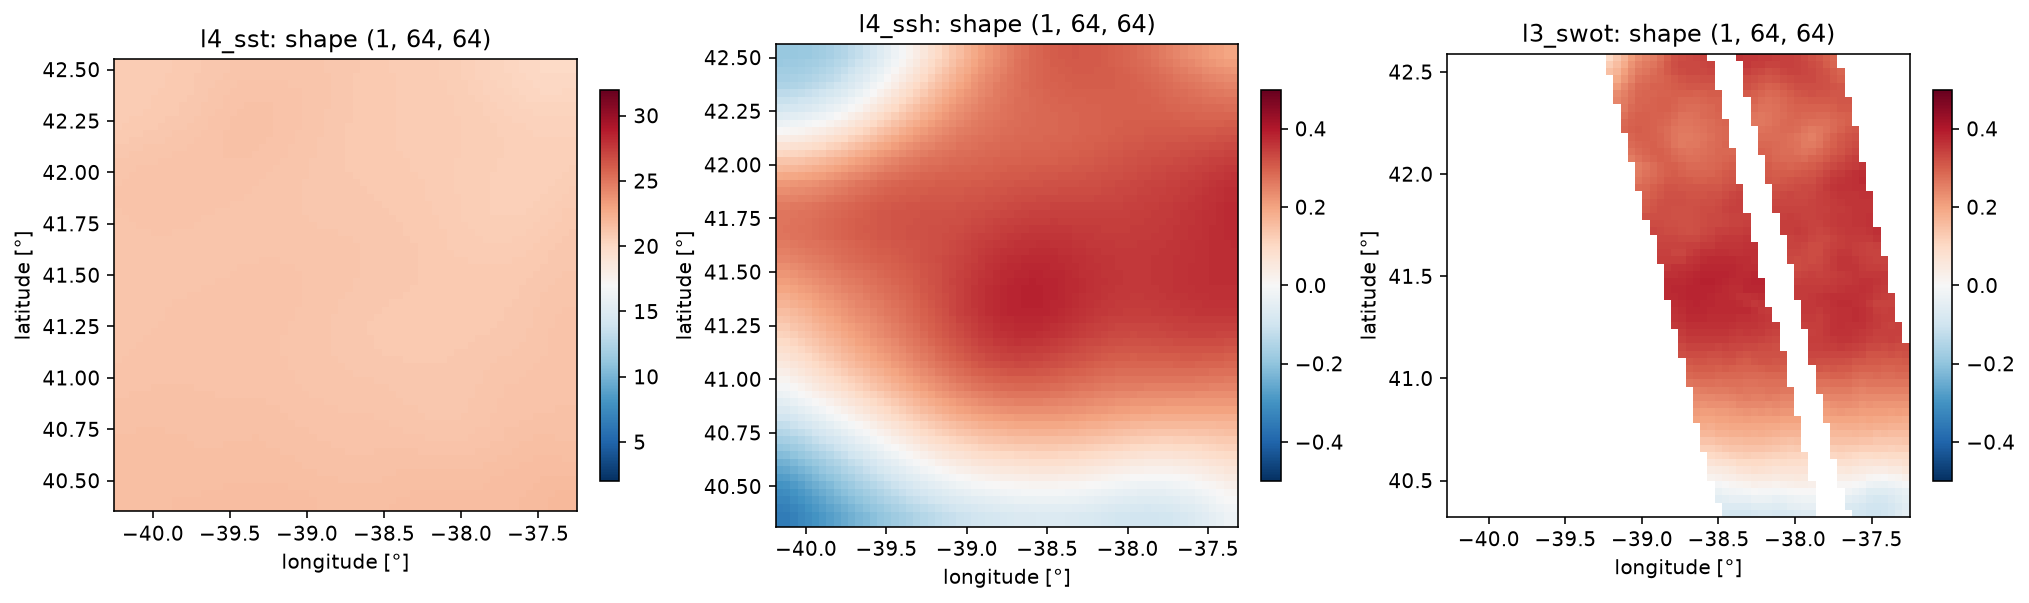

All three share one model-facing grid, and their masks stay separate.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, token in zip(axes, ("l4_sst", "l4_ssh", "l3_swot")):
    show_grid(axis, fusion_sample[token], token, key=token)
display_figure(fig)
print("All three share one model-facing grid, and their masks stay separate.")

## `VectorPair`: two components as one field

When configured independently, eastward and northward velocity components can
have different valid regions. A valid `u` with an invalid `v` does not define
a measured vector.

`VectorPair` produces both components together as `(T, 2, H, W)`. Its
`valid_mask` requires support for both components, and `pair_available` gives
sample-level availability. The shared asset is fetched once.

For `VectorPair(Resample(...))`, `source_valid`, `support`, `support_mask`, and
`valid_mask` all have shape `(T, H, W)` on the output grid; the component axis
appears only in `data`. `source_valid` equals `support > 0`, with support
computed jointly from both components. Because that shape is fixed by the
output grid rather than the native one, batches collate even when rows have
differing native shapes or a missing record. `VectorPair(Native())` keeps its
native masks.


In [7]:
vectors = {"velocity": VectorPair(Resample((64, 64), .5))}
print("components:", vectors["velocity"].components)
velocity_sample = render(vectors)
velocity = velocity_sample["velocity"]
data = np.asarray(velocity["data"])
mask_shape = (data.shape[0], *data.shape[-2:])
for key in ("source_valid", "support", "support_mask", "valid_mask"):
    assert tuple(velocity[key].shape) == mask_shape
np.testing.assert_array_equal(velocity["source_valid"], np.asarray(velocity["support"]) > 0)
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    print(f"u range=[{np.nanmin(data[:, 0]):.3f}, {np.nanmax(data[:, 0]):.3f}] m/s")
    print(f"v range=[{np.nanmin(data[:, 1]):.3f}, {np.nanmax(data[:, 1]):.3f}] m/s")
    print(f"speed max={np.nanmax(speed):.3f} m/s, pair_available={bool(velocity['pair_available'])}")

components: ('glorys_uo', 'glorys_vo')


  velocity   data=(1, 2, 64, 64)     available=True  valid_cells=4096
u range=[-0.704, 0.586] m/s
v range=[-0.413, 0.457] m/s
speed max=0.717 m/s, pair_available=True


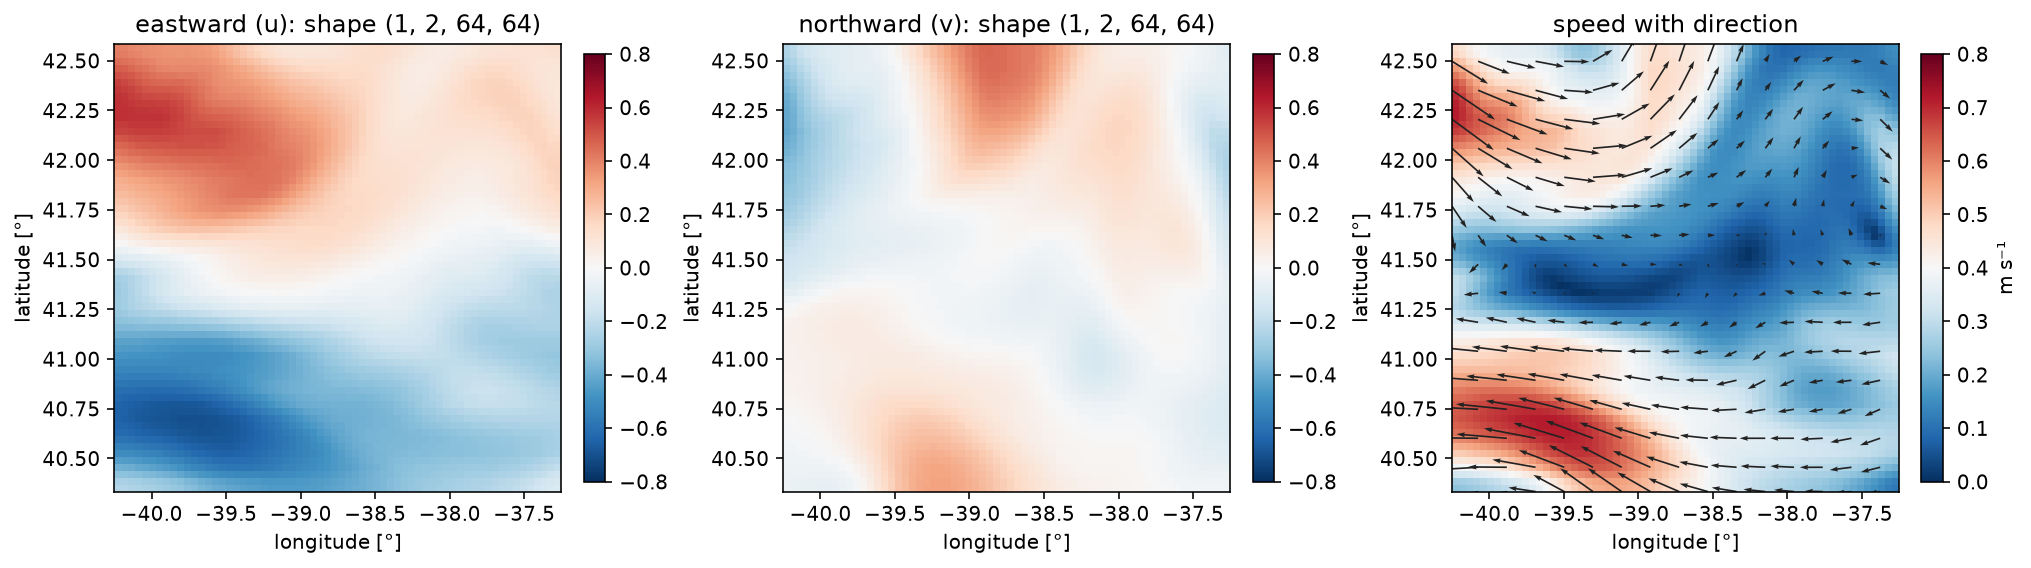

One shared mask governs both components, so every drawn arrow has support in each.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
show_grid(axes[0], velocity, "eastward (u)", component=0, key="velocity")
show_grid(axes[1], velocity, "northward (v)", component=1, key="velocity")
data = np.asarray(velocity["data"])
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    extent = geographic_extent(velocity)
    drawn = axes[2].imshow(speed, origin="lower", cmap=CMAP, interpolation="nearest",
                           aspect=map_aspect(extent), extent=extent, **color_limits("speed"))
    step = max(1, speed.shape[0] // 16)
    grid_x, grid_y = np.meshgrid(np.asarray(velocity["lon"]).ravel()[::step],
                                 np.asarray(velocity["lat"]).ravel()[::step])
    axes[2].quiver(grid_x, grid_y, data[0][0][::step, ::step], data[0][1][::step, ::step], color="#222222", scale=6)
    axes[2].set(title="speed with direction", xlabel="longitude [°]", ylabel="latitude [°]")
    add_coastlines(axes[2])
    fig.colorbar(drawn, ax=axes[2], shrink=.8, label="m s⁻¹")
else:
    axes[2].text(.5, .5, "pair unavailable", ha="center", va="center", transform=axes[2].transAxes)
display_figure(fig)
print("One shared mask governs both components, so every drawn arrow has support in each.")

## Sparse and dense sources in one configuration

A missing SWOT cell means the satellite did not sample that location. Preserve
this distinction when combining complete L4 fields with sparse L3 swaths. Use
`valid_mask` for model inputs and losses; zero is a plausible sea-level
anomaly and cannot be used as a sentinel.

In [9]:
sparse_dense = {"l4_sst": Resample((64, 64), .5), "l3_swot": Resample((64, 64), .5)}
sparse_sample = render(sparse_dense)
for token in sparse_dense:
    mask = np.asarray(sparse_sample[token]["valid_mask"])
    if mask.size:
        print(f"{token:10s} valid fraction={mask.mean():.3f}")
print("A low valid fraction is evidence about sampling, not about the ocean.")

  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=1718
l4_sst     valid fraction=1.000
l3_swot    valid fraction=0.419
A low valid fraction is evidence about sampling, not about the ocean.


## `Points`: ragged Argo records

Argo observations are profiles at float locations, not gridded fields. `Points`
returns ragged records with coordinates and pressure, and record counts vary by
row. Zero points is a valid result because most patches contain no floats on a
given day.

`variable` selects the measurement, and `pres_range` limits the depth band in
decibars. Without `pres_range`, the configuration uses the shallowest valid level
per profile. The example requests the upper 200 dbar.

The selected row was drawn with a `profile_count` condition to ensure that it
contains floats. The following survey measures their frequency in an
unconditioned draw.

The left panel shows one marker because a float profiles at one location. Its
records differ by depth, shown in the right-hand temperature profile. In the
unconditioned draw above, one float per 256 km patch is typical.

In [10]:
points = {"argo": Points(variable="TEMP", pres_range=(0, 200))}
argo_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                          record_path=DRAW_DIR / "argo-draw.json",
                          query_filter=QueryFilter(box=GeoBox(-80, -30, 10, 45),
                                                   coverage=(CoverageRequirement("argo", "profile_count", 1),)))
argo_row = argo_draw.rows[0]
print(f"row: ({argo_row['centre_lon']:.2f}, {argo_row['centre_lat']:.2f}) on {argo_row['anchor_time'][:10]}")
argo_sample = OceanTACODataset(queries=argo_draw, sources=points, catalog_config=config)[0]
record = argo_sample["argo"]
print("available:", argo_sample["availability"]["argo"])
for key in ("data", "lat", "lon", "pres"):
    if key in record:
        print(f"  {key:6s} shape={tuple(np.asarray(record[key]).shape)}")
print(f"{int(np.asarray(record['data']).size)} point records. The count is per patch and varies.")

row: (-58.15, 41.45) on 2023-08-25


available: True
  data   shape=(55,)
  lat    shape=(55,)
  lon    shape=(55,)
  pres   shape=(55,)
55 point records. The count is per patch and varies.


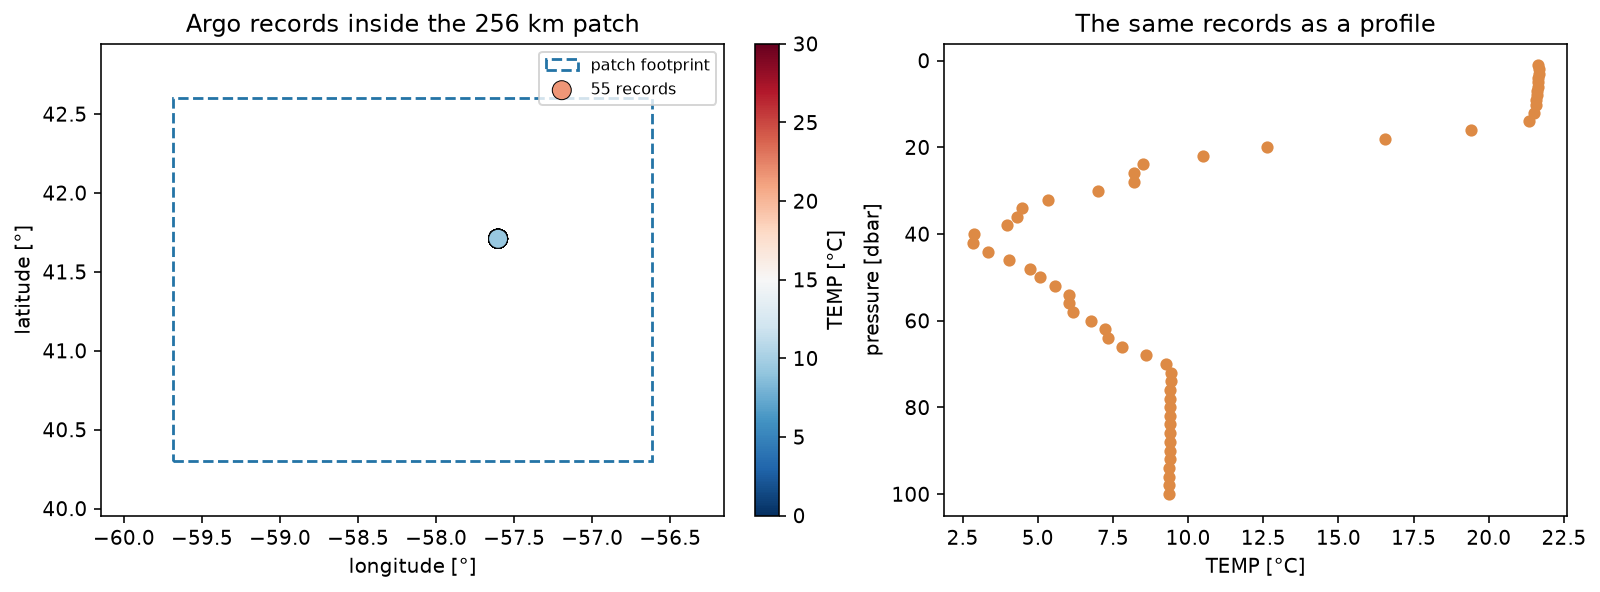

Points keep their own coordinates and pressures, and nothing is rasterised onto a grid.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
lon, lat = np.asarray(record.get("lon", [])), np.asarray(record.get("lat", []))
values = np.asarray(record["data"]).reshape(-1)
if lon.size:
    lon_span, lat_span = PatchSize(PATCH_SIZE_KM, "km").to_degrees(centre_lat=argo_row["centre_lat"])
    axes[0].add_patch(plt.Rectangle((argo_row["centre_lon"] - lon_span / 2, argo_row["centre_lat"] - lat_span / 2),
                                    lon_span, lat_span, fill=False, edgecolor="#2474a6",
                                    linewidth=1.4, linestyle="--", label="patch footprint"))
    drawn = axes[0].scatter(lon, lat, c=values[:lon.size], s=90, cmap=CMAP, zorder=3,
                            edgecolor="black", linewidth=.5, label=f"{lon.size} records",
                            **color_limits("argo_temp"))
    fig.colorbar(drawn, ax=axes[0], label="TEMP [°C]")
    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].set(xlim=(argo_row["centre_lon"] - lon_span * .65, argo_row["centre_lon"] + lon_span * .65),
                ylim=(argo_row["centre_lat"] - lat_span * .65, argo_row["centre_lat"] + lat_span * .65))
    add_coastlines(axes[0])
    pres = np.asarray(record["pres"]).reshape(-1)
    axes[1].scatter(values[:pres.size], pres, s=26, color="#dd8a45")
    axes[1].invert_yaxis()
    axes[1].set(title="The same records as a profile", xlabel="TEMP [°C]", ylabel="pressure [dbar]")
else:
    for axis in axes:
        axis.text(.5, .5, "no Argo profiles in this patch", ha="center", va="center", transform=axis.transAxes)
axes[0].set_title("Argo records inside the 256 km patch")
axes[0].set(xlabel="longitude [°]", ylabel="latitude [°]")
display_figure(fig)
print("Points keep their own coordinates and pressures, and nothing is rasterised onto a grid.")

In [12]:
survey = draw_queryset(queryset, requested_row_count=20, seed=29,
                       record_path=DRAW_DIR / "argo-survey-draw.json")
survey_dataset = OceanTACODataset(queries=survey, sources=points, catalog_config=config)
counts = [int(np.asarray(survey_dataset[index]["argo"]["data"]).size) for index in range(len(survey.rows))]
print(f"rows with at least one profile: {sum(count > 0 for count in counts)} of {len(counts)}")
print("Zero is the ordinary case at this patch size, which is why the configuration above conditions its draw.")

rows with at least one profile: 1 of 20
Zero is the ordinary case at this patch size, which is why the configuration above conditions its draw.


## `Native`: the source grid, and bucketing

`Native()` preserves the source grid and does not interpolate cells. Shapes can
vary by row, so they cannot be stacked directly. `ShapeBucketSampler` groups
rows with matching native shapes into uniform batches without padding.

Set `shuffle=False` for a reproducible bucket order. By default, rows are
shuffled within and across buckets. The
[ML use cases notebook](spatio_temporal_query_generation.ipynb) uses this
sampler with a `DataLoader`.

In [13]:
native_sample = render({"l3_swot": Native()})
resampled = np.asarray(fusion_sample["l3_swot"]["data"])
native = np.asarray(native_sample["l3_swot"]["data"])
print(f"native shape={native.shape}, resampled shape={resampled.shape}")
print("Native preserves the source grid exactly. Resample fixes the shape and pays interpolation for it.")

  l3_swot    data=(1, 128, 121)      available=True  valid_cells=6271
native shape=(1, 128, 121), resampled shape=(1, 64, 64)
Native preserves the source grid exactly. Resample fixes the shape and pays interpolation for it.


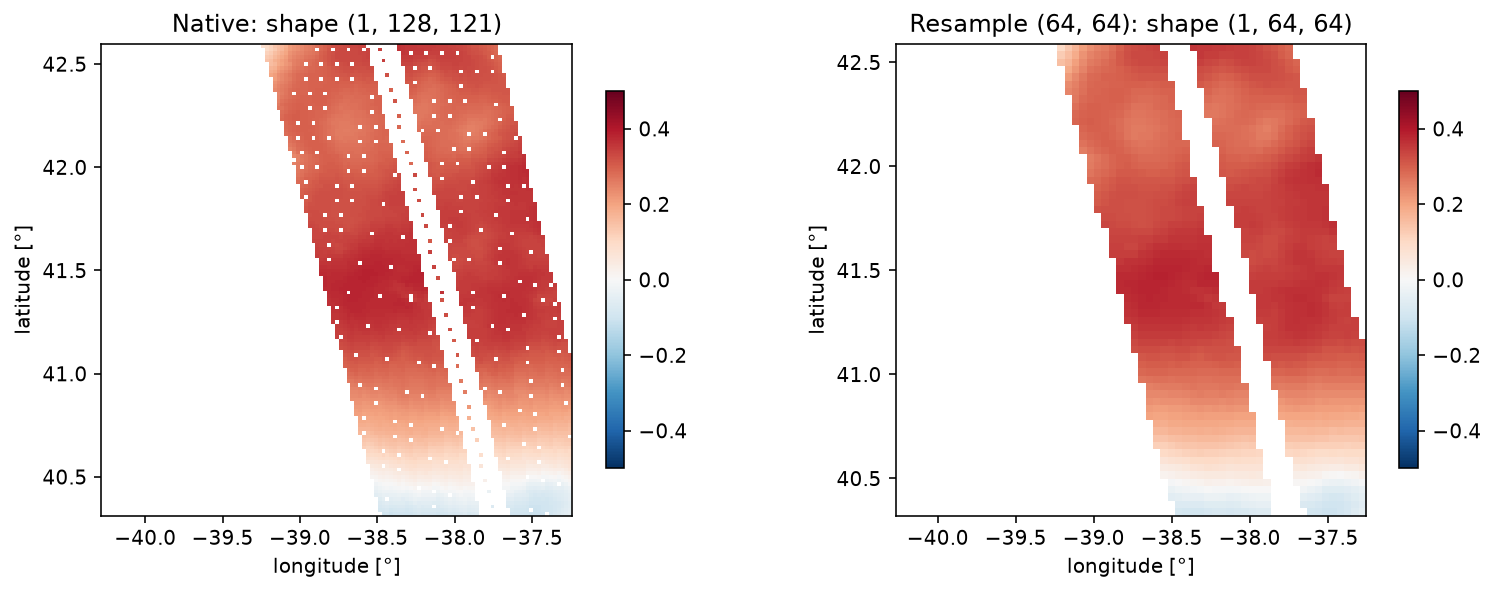

Same row and same colour range, so the difference between the panels is resolution alone.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
show_grid(axes[0], native_sample["l3_swot"], "Native", key="l3_swot")
show_grid(axes[1], fusion_sample["l3_swot"], "Resample (64, 64)", key="l3_swot")
display_figure(fig)
print("Same row and same colour range, so the difference between the panels is resolution alone.")

In [15]:
from ocean_taco.torch import ShapeBucketSampler
shapes = [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
sampler = ShapeBucketSampler(shapes, batch_size=2, seed=19, shuffle=False)
batches = list(sampler)
print("native shapes:", shapes)
print("batches:", batches)
for batch in batches:
    print("  ", [shapes[index] for index in batch], "-> uniform:", len({shapes[index] for index in batch}) == 1)

native shapes: [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
batches: [[0, 1], [4], [2, 3]]
   [(32, 48), (32, 48)] -> uniform: True
   [(32, 48)] -> uniform: True
   [(40, 48), (40, 48)] -> uniform: True


## Regional and antimeridian boxes

A regional box resolves to one longitude segment. A box crossing the
antimeridian resolves to two, avoiding an ambiguous interval from 170 to −170.
This keeps downstream checks as ordinary interval comparisons. The
[deep-dive](data_retrieval_workflows.ipynb) plots the geometry.

In [16]:
regional = GeoBox(-80, -30, 10, 45)
wrapped = GeoBox(170, -170, 10, 30, wraps_antimeridian=True)
print("regional segments:", len(regional.segments()))
for segment in wrapped.segments():
    print("  wrapped segment:", segment.to_dict())
print(f"regional selection: {select_queryset(queryset, QueryFilter(box=regional)).count:,} pairs")

regional segments: 1
  wrapped segment: {'lon_min': 170, 'lon_max': 180.0, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
  wrapped segment: {'lon_min': -180.0, 'lon_max': -170, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
regional selection: 290,862 pairs


## Normalisation

Normalisation is an experiment setting and should be stored with the run. The
loader returns decoded values in their recorded units. Apply normalisation with
`valid_mask` so invalid cells remain NaN, and compute statistics once from the
training rows.

`l3_swot` makes the effect visible because its swath covers only part of the
patch. Zero-filling treats unobserved cells as measurements and biases the
mean toward zero.

In [17]:
import torch
def normalise_valid(data, mask, mean, std):
    output = torch.full_like(data, float("nan"))
    output[mask] = (data[mask] - mean) / torch.as_tensor(std, dtype=data.dtype).clamp_min(1e-6)
    return output

values, mask = fusion_sample["l3_swot"]["data"], fusion_sample["l3_swot"]["valid_mask"]
mean, std = values[mask].mean(), values[mask].std()
normalised = normalise_valid(values, mask, mean, std)
print(f"source mean={mean:.4f} std={std:.4f} over {int(mask.sum())} of {mask.numel()} cells")
print(f"normalised mean={normalised[mask].mean():.3e} std={normalised[mask].std():.3f}")
print(f"{int((~mask).sum())} invalid cells, all still NaN: {bool(torch.isnan(normalised[~mask]).all())}")
filled = torch.nan_to_num(values, nan=0.0)
print(f"masked mean={mean:.4f} against zero-filled mean={filled.mean():.4f}")

source mean=0.2664 std=0.1126 over 1718 of 4096 cells
normalised mean=1.840e-07 std=1.000
2378 invalid cells, all still NaN: True
masked mean=0.2664 against zero-filled mean=0.1117
